# Notebook 03 — Feature Engineering
**Project: Coastal Property Catastrophe Loss Model**

Transform raw NFIP claims into the 20-feature matrix used by the frequency and severity models.

## Features Built
| Feature | Source | Rationale |
|---|---|---|
| `flood_zone_risk_score` | NFIP floodZone | Primary risk driver |
| `is_coastal_high_risk` | NFIP floodZone | V/VE zone flag |
| `is_high_risk_zone` | NFIP floodZone | SFHA indicator |
| `occupancy_is_residential` | NFIP occupancyType | Loss pattern differs |
| `has_basement` | NFIP basementType | Flood depth exposure |
| `log_building_coverage` | NFIP coverage | Scale of exposure |
| `coverage_to_value_ratio` | NFIP coverage/value | Adverse selection proxy |
| `num_floors` | NFIP floors | Upper floors avoid flood |
| `construction_age_years` | NFIP construction date | Older = more vulnerable |
| `is_post_firm` | NFIP construction date | Regulatory compliance |
| `has_elevation_cert` | NFIP elevCert | Risk mitigation indicator |
| `hurricane_risk_score` | NOAA category | Storm intensity |
| `is_hurricane_peril` | NOAA event type | Event type flag |
| `is_flood_peril` | NOAA event type | Event type flag |
| `is_coastal_state` | reportedState | Geographic risk |
| `log_storm_damage` | NOAA damage | Storm magnitude proxy |

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from feature_engineering import FeaturePipeline, SEVERITY_FEATURES

DATA_DIR = Path('../data/raw')
claims = pd.read_parquet(DATA_DIR / 'nfip_claims_enriched.parquet')
print(f'Loaded {len(claims):,} records')

Loaded 336,662 records


## 1. Run Feature Pipeline

In [2]:
pipeline = FeaturePipeline(reference_year=2023)
X, y_sev, y_freq = pipeline.fit_transform(claims, return_targets=True)

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {list(X.columns)}')
print(f'\nFrequency target (y_freq):')
print(f'  Positive: {y_freq.sum():,} ({y_freq.mean():.1%})')
print(f'  Negative: {(y_freq == 0).sum():,}')
print(f'\nSeverity target (y_sev):')
print(f'  Valid (non-NaN): {y_sev.notna().sum():,}')
print(f'  Mean log-severity: {y_sev.dropna().mean():.2f}')
print(f'  Std log-severity:  {y_sev.dropna().std():.2f}')
print(f'  → Mean dollar:     ${np.exp(y_sev.dropna().mean()):,.0f}')

Feature matrix shape: (336662, 20)
Features: ['flood_zone_risk_score', 'is_coastal_high_risk', 'is_high_risk_zone', 'occupancy_is_residential', 'occupancy_is_nonresidential', 'has_basement', 'log_building_coverage', 'log_contents_coverage', 'has_contents_coverage', 'coverage_to_value_ratio', 'num_floors', 'construction_age_years', 'is_post_firm', 'has_elevation_cert', 'hurricane_risk_score', 'is_hurricane_peril', 'is_flood_peril', 'latitude', 'longitude', 'log_storm_damage']

Frequency target (y_freq):
  Positive: 258,897 (76.9%)
  Negative: 77,765

Severity target (y_sev):
  Valid (non-NaN): 258,534
  Mean log-severity: 9.89
  Std log-severity:  1.49
  → Mean dollar:     $19,638


## 2. Feature Statistics

In [3]:
print('Feature matrix summary:')
display(X.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std']))

Feature matrix summary:


,count,mean,std,min,25%,50%,75%,max
flood_zone_risk_score,336662.000000,0.519894,0.191948,0.100000,0.400000,0.400000,0.750000,1.000000
is_coastal_high_risk,336662.000000,0.021850,0.146193,0.000000,0.000000,0.000000,0.000000,1.000000
is_high_risk_zone,336662.000000,0.362958,0.480853,0.000000,0.000000,0.000000,1.000000,1.000000
occupancy_is_residential,336662.000000,0.944247,0.229445,0.000000,1.000000,1.000000,1.000000,1.000000
occupancy_is_nonresidential,336662.000000,0.055753,0.229445,0.000000,0.000000,0.000000,0.000000,1.000000
has_basement,336662.000000,0.226984,0.418883,0.000000,0.000000,0.000000,0.000000,1.000000
log_building_coverage,336662.000000,11.878426,1.640307,0.693147,11.736077,12.429220,12.429220,19.423149
log_contents_coverage,336662.000000,7.850860,4.801283,0.000000,0.000000,10.308986,11.477309,14.914123
has_contents_coverage,336662.000000,0.733442,0.442160,0.000000,0.000000,1.000000,1.000000,1.000000
coverage_to_value_ratio,336662.000000,1.143341,0.493170,0.000000,0.879819,1.000000,1.465870,2.000000


## 3. Feature Distributions

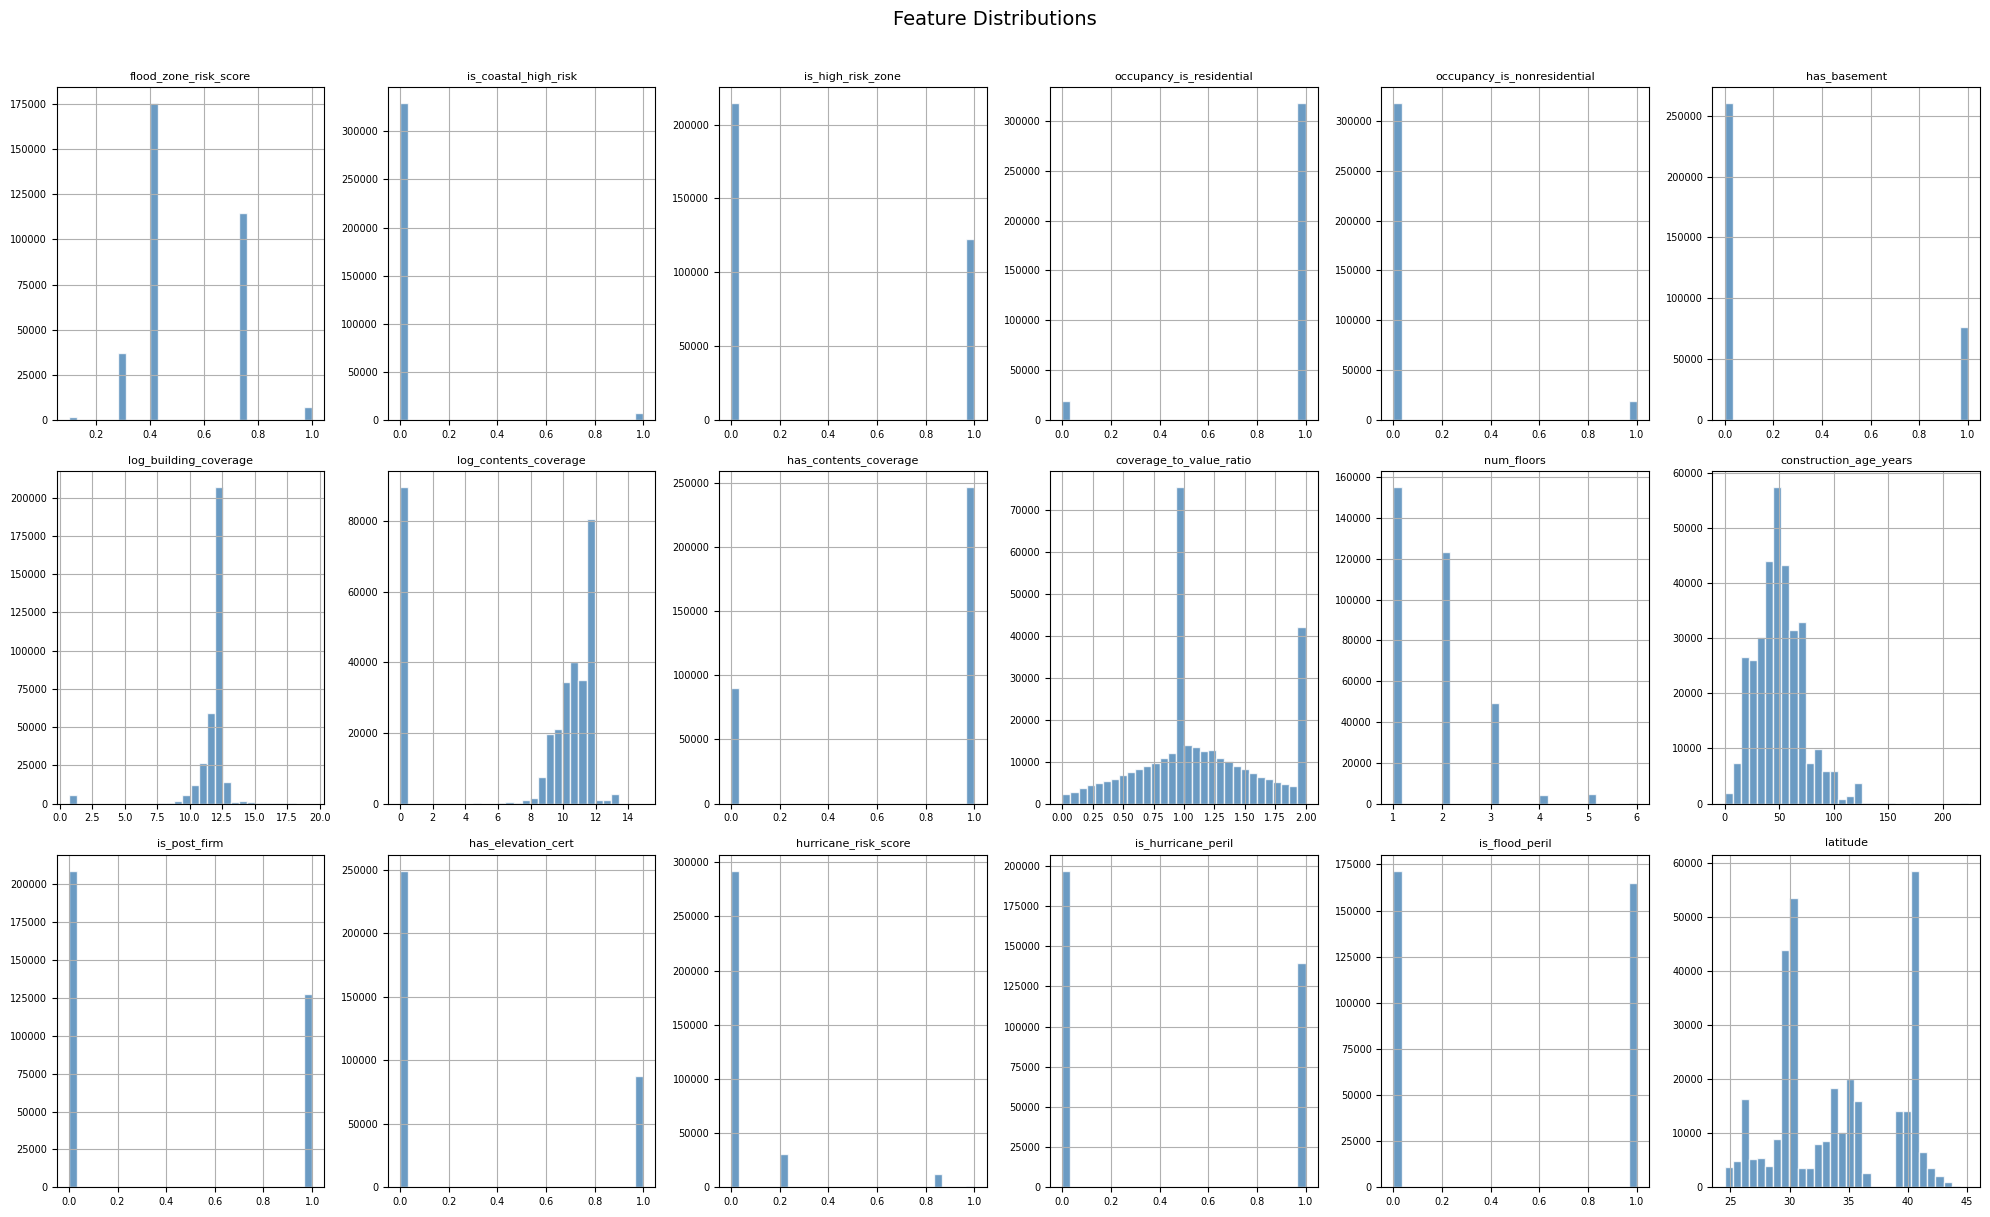

In [4]:
fig, axes = plt.subplots(3, 6, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(SEVERITY_FEATURES):
    if i >= len(axes):
        break
    X[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)

# Hide empty subplots
for j in range(len(SEVERITY_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/fig_03_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Feature Correlation with Targets

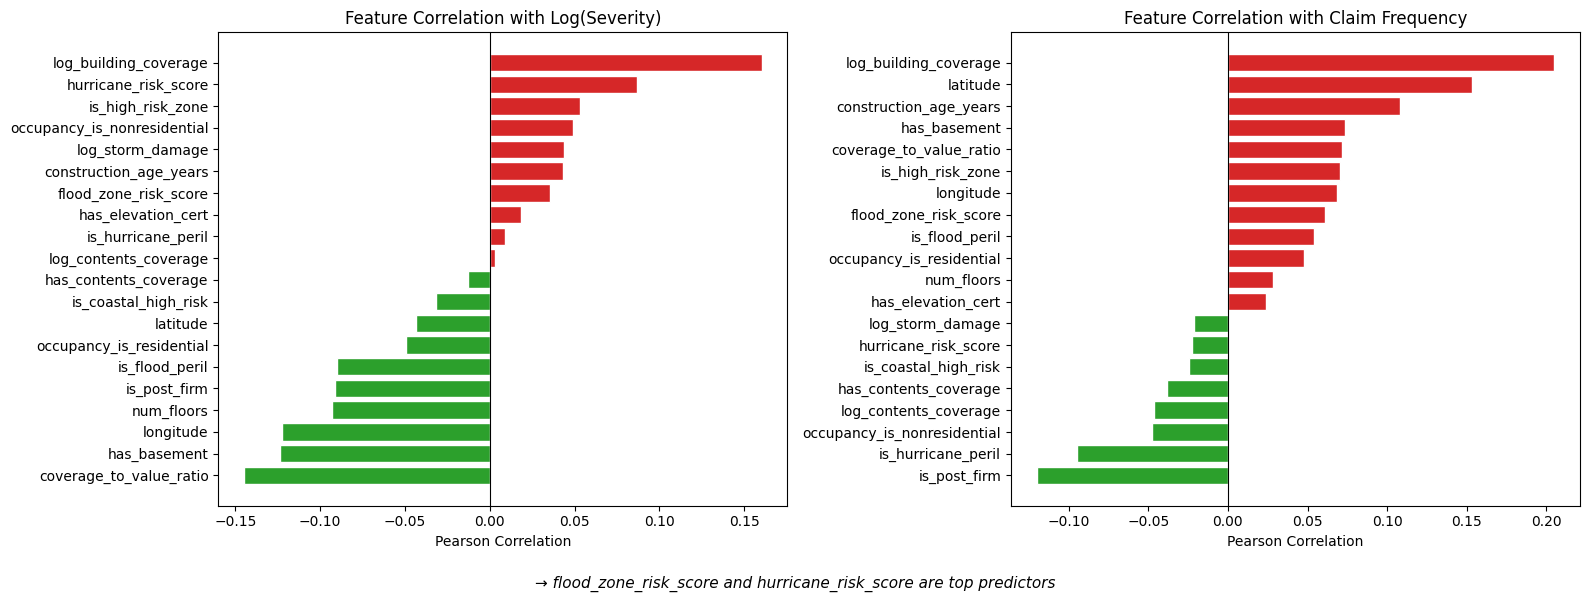

In [5]:
# Correlate features with severity target
analysis_df = X.copy()
analysis_df['log_severity'] = y_sev
analysis_df['has_claim'] = y_freq

sev_corr = analysis_df.dropna().corr()['log_severity'].drop(['log_severity', 'has_claim'])
freq_corr = analysis_df.corr()['has_claim'].drop(['log_severity', 'has_claim'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Severity correlations
sev_sorted = sev_corr.sort_values()
colors = ['#d62728' if v > 0 else '#2ca02c' for v in sev_sorted]
axes[0].barh(sev_sorted.index, sev_sorted.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with Log(Severity)', fontsize=12)
axes[0].set_xlabel('Pearson Correlation')

# Frequency correlations
freq_sorted = freq_corr.sort_values()
colors = ['#d62728' if v > 0 else '#2ca02c' for v in freq_sorted]
axes[1].barh(freq_sorted.index, freq_sorted.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Claim Frequency', fontsize=12)
axes[1].set_xlabel('Pearson Correlation')

plt.suptitle('→ flood_zone_risk_score and hurricane_risk_score are top predictors', 
             y=-0.02, style='italic', fontsize=11)
plt.tight_layout()
plt.savefig('../data/fig_03_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save Feature Matrix for Model Training

In [6]:
# Save feature matrix + targets
features_path = DATA_DIR / 'features.parquet'
X.to_parquet(features_path, index=False)

targets = pd.DataFrame({'log_severity': y_sev, 'has_claim': y_freq})
targets.to_parquet(DATA_DIR / 'targets.parquet', index=False)

print(f'Saved feature matrix: {features_path}')
print(f'Shape: {X.shape}')
print('\n✅ Notebook 03 complete — proceed to 04_severity_model.ipynb')

Saved feature matrix: ..\data\raw\features.parquet
Shape: (336662, 20)

✅ Notebook 03 complete — proceed to 04_severity_model.ipynb
